## Setup

In [1]:
from scipy.integrate import solve_ivp
from scipy.signal import hilbert
import numpy as np
import yaml, os, string
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import hilbert, welch
# ============================================================
# Global plotting style
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 20,
    "axes.linewidth": 1.1,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})


def format_axis(ax):
    """Apply consistent formatting to ordinary axes."""
    ax.tick_params(axis="both", direction="out", length=4, width=1.1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_panel_label(ax, letter, dx=-0.18, dy=1.5):
    """Bold panel letter (A, B, C, ...) in the top-left corner of a subplot."""
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=22, fontweight="bold",
            va="bottom", ha="left")

## Rossler network model

In [2]:
class RosslerNetwork:

    def __init__(self, N, a, b, c, Iext, d, k, omega):
        self.N = N
        self.a = a
        self.b = b
        self.c = c
        self.Iext = Iext
        self.d = d
        self.k = k
        self.omega = omega

    def network(self, t, xyz):
        x = np.array(xyz[0:self.N])
        y = np.array(xyz[self.N:2*self.N])
        z = np.array(xyz[2*self.N:3*self.N])
        x_mean = np.mean(x)

        dxdt = -self.omega * y - z + self.k * 0.05 * (self.d - x_mean) + (0.5 - self.k) * (0.5 * x_mean - x)
        dydt = self.omega * x + self.a * y
        dzdt = self.b + z * (x - self.c) + self.Iext
        diff = []
        diff.extend(dxdt)
        diff.extend(dydt)
        diff.extend(dzdt)
        return np.array(diff).flatten()

    def run(self, time_sec=3):
        x_initial = np.random.normal(0, 0.001, self.N)
        y_initial = np.random.normal(0, 0.001, self.N)
        z_initial = np.random.normal(0, 0.001, self.N)
        initial_vals = []
        initial_vals.extend(x_initial)
        initial_vals.extend(y_initial)
        initial_vals.extend(z_initial)

        t_span = (0, int(time_sec * 100))
        t_eval = np.linspace(*t_span, int(50000 * time_sec))

        sol = solve_ivp(self.network, t_span, initial_vals, t_eval=t_eval,
                         vectorized=True, method='RK45', dense_output=True)
        return sol

## Parameters

In [3]:
TOTAL_SAMPLES, N_TRANSIENT, ITERS = 4_00_000, 3_00_000, 50
P = dict(N=100, a=0.2, b=0.2, c=5.7, Iext=0, d=0.5)
OMEGA = 0.8

num_arms = 3
D1        =  np.array([20, 40, 30])/100  #np.array([20, 40, 30])   # learned D1 "Go" drive per arm (arm 1 = greedy)
d1_amp    = 1.0 #0.7 #0.495 #1.0
d2_amp    = 0.4 #0.4 #50.0        # calibrated for these params: sync 0% explore, desync ~32%
gpi_threshold, max_gpi_iters, gpi_mean = 0.26, 50, 1.0

K_SYNC, K_DESYNC = 0.42, 0.53
osc_no    = np.array([80, 33, 5])  #np.array([0, 33, 66])          # 3 Rossler oscillators -> arms 0,1,2
time_sec, base_seed = 4.0, 100 #5

step = 0.01 / 0.1        # dt/tau_gpi = 0.1, as in BGNetwork

## Simulation

`run_rossler_condition` replaces the old `rossler_stn()` + `rossler_grid_frames()` pair, which each independently re-ran the same ODE solve for the same `(k, seed)` just to extract different slices. It now solves once per condition and derives the 3-arm race signal, the 10x10 phase grid, the Kuramoto order parameter (phase synchrony), and the phase-distribution entropy from that single run.

In [4]:
def race(stn):
    stn = stn.T; v = np.zeros(num_arms)
    tv, w, ct = [], None, len(stn) - 1
    for t in range(len(stn)):
        d2 = d2_amp * stn[t]
        v = v + step * (-v - d1_amp * D1 + d2); vo = -v
        tv.append(vo.copy())
        if vo.max() > gpi_threshold: w, ct = int(np.argmax(vo)), t; break
    if w is None: w = int(np.argmax(vo))
    return np.array(tv), w, ct



In [5]:
from scipy.fft import fft
from scipy.ndimage import gaussian_filter1d

def spectral_entropy(x_mean, sr, sigma=5, band=(10, 60)):
    """Spectral entropy of a 1D time series (here: the population mean x_mean(t)),
    restricted to a frequency band, computed the same way as your FFT pipeline:
    raw FFT -> positive-frequency magnitude spectrum -> Gaussian smoothing ->
    restrict to `band` Hz -> normalize to a probability distribution -> Shannon
    entropy (normalized by log(n_bins_in_band), so the result sits in [0, 1]):
      0 = power concentrated at a single frequency within the band (periodic)
      1 = power spread uniformly across the band (flat/noise-like)
    `sr` is the actual sampling rate in Hz -- it must match how x_mean was
    generated, or the band restriction will select the wrong bins.
    """
    N = len(x_mean)
    freqs = np.fft.fftfreq(N, d=1 / sr)[:N // 2]     # positive-frequency axis, in Hz
    fft_out = fft(x_mean)
    mag = np.abs(fft_out[:N // 2])
    mag_smooth = gaussian_filter1d(mag, sigma=sigma)  # smooth over the full spectrum first,
                                                        # so bins right at the band edge aren't
                                                        # truncated before smoothing sees them

    band_mask = (freqs >= band[0]) & (freqs <= band[1])
    n_bins = band_mask.sum()
    if n_bins < 2:
        raise ValueError(
            f"Only {n_bins} FFT bin(s) fall within {band} Hz at sr={sr}, N={N} "
            f"(frequency resolution is {sr / N:.3f} Hz/bin) -- band is too narrow "
            f"or the signal too short/sr too low to resolve it."
        )
    mag_band = mag_smooth[band_mask]

    p = mag_band / mag_band.sum()
    p = np.clip(p, 1e-12, None)
    H = -(p * np.log(p)).sum() / np.log(n_bins)
    return float(H)

def run_rossler_condition(k, seed, n_frames=200, grid_shape=(10, 10), sr=50000, sigma=5):
    """... (unchanged docstring except H)
      - H : spectral entropy of the population mean x_mean(t) (0 = periodic
            mean-field, 1 = flat/noise-like), via raw-FFT + Gaussian-smoothed
            magnitude spectrum, same method as your DBS/X_mean FFT pipeline
    """
    # data = yaml.safe_load(open(os.path.join('BasalGanglia', 'params.yaml')))

    data = {'a' : 0.2,
            'b' : 0.2,
            'c' : 5.7,
            'N' : 100,
            'Iext' : 0,
            'd' : 0.5,
            'omega' : 0.8
}
    n_grid = grid_shape[0] * grid_shape[1]
    assert data['N'] == n_grid, f"data['N']={data['N']} does not match grid_shape {grid_shape} ({n_grid} cells)"

    omega = np.ones((data['N'], 1)) * data['omega']
    RN = RosslerNetwork(N=data['N'], a=data['a'], b=data['b'], c=data['c'],
                        d=data['d'], k=k, omega=omega, Iext=data['Iext'])
    np.random.seed(seed)
    sim_time_sec = TOTAL_SAMPLES / 50000
    sol = RN.run(time_sec=sim_time_sec)
    x = np.array(sol.y)[0:data['N'], 50000:]            # (N, kept) -- drop transient
    x_mean = x.mean(axis=0)                                    # (kept,) -- population mean
    x = np.array(sol.y)[0:data['N'], N_TRANSIENT:]            # (N, kept) -- drop transient
    osc = x[osc_no]
    keep_race = (osc.shape[1] // ITERS) * ITERS
    sig = osc[:, :keep_race].reshape(num_arms, ITERS, -1).mean(2)   # (3, ITERS)

    phase = np.angle(hilbert(x, axis=1))                      # (N, kept)

    keep = (x.shape[1] // n_frames) * n_frames
    grid_frames = x[:, :keep].reshape(n_grid, n_frames, -1).mean(2)   # (N, n_frames) time-bin average
    grid_frames = grid_frames.T.reshape(n_frames, *grid_shape)              # (n_frames, 10, 10)

    R_t = np.abs(np.mean(np.exp(1j * phase), axis=0))
    R = float(R_t.mean())

    

    return dict(sig=sig, grid_frames=grid_frames, R=R)

## Run both conditions

In [6]:

greedy = int(np.argmax(D1))
colors = plt.cm.tab10(np.linspace(0, 1, 10)); ac = {a: colors[a] for a in range(num_arms)}

snap_idx = np.array([2, 49, 110, 137, 163])
n_snap = len(snap_idx)
n_frames_grid = 200
time = np.linspace(0, 500, 50)

conds = [K_SYNC, K_DESYNC]
cond_labels = [
    "Synchronised and low entropy STN-GPe dynamics",
    "Desynchronised and high entropy STN-GPe dynamics",
]

cond_data = []
for r, k in enumerate(conds):
    out = run_rossler_condition(k, base_seed + r, n_frames=n_frames_grid, grid_shape=(10, 10))
    tv, w, ct = race(out['sig'])
    it = np.linspace(0, int(len(tv) * 10), len(tv))
    ct_time = (ct + 1) * 10
    cond_data.append(dict(k=k, sig=out['sig'], tv=tv, w=w, ct=ct, it=it, ct_time=ct_time,
                           grid_frames=out['grid_frames'], R=out['R']))

print(f"{'condition':<14}{'k':>6}{'  R (sync)':>12}")
for d in cond_data:
    print(f"{'k='+str(d['k']):<14}{d['k']:>6.3g}{d['R']:>12.3f}")

condition          k    R (sync)
k=0.42          0.42       0.996
k=0.53          0.53       0.112


## Figure 1 -- Action-selection dynamics

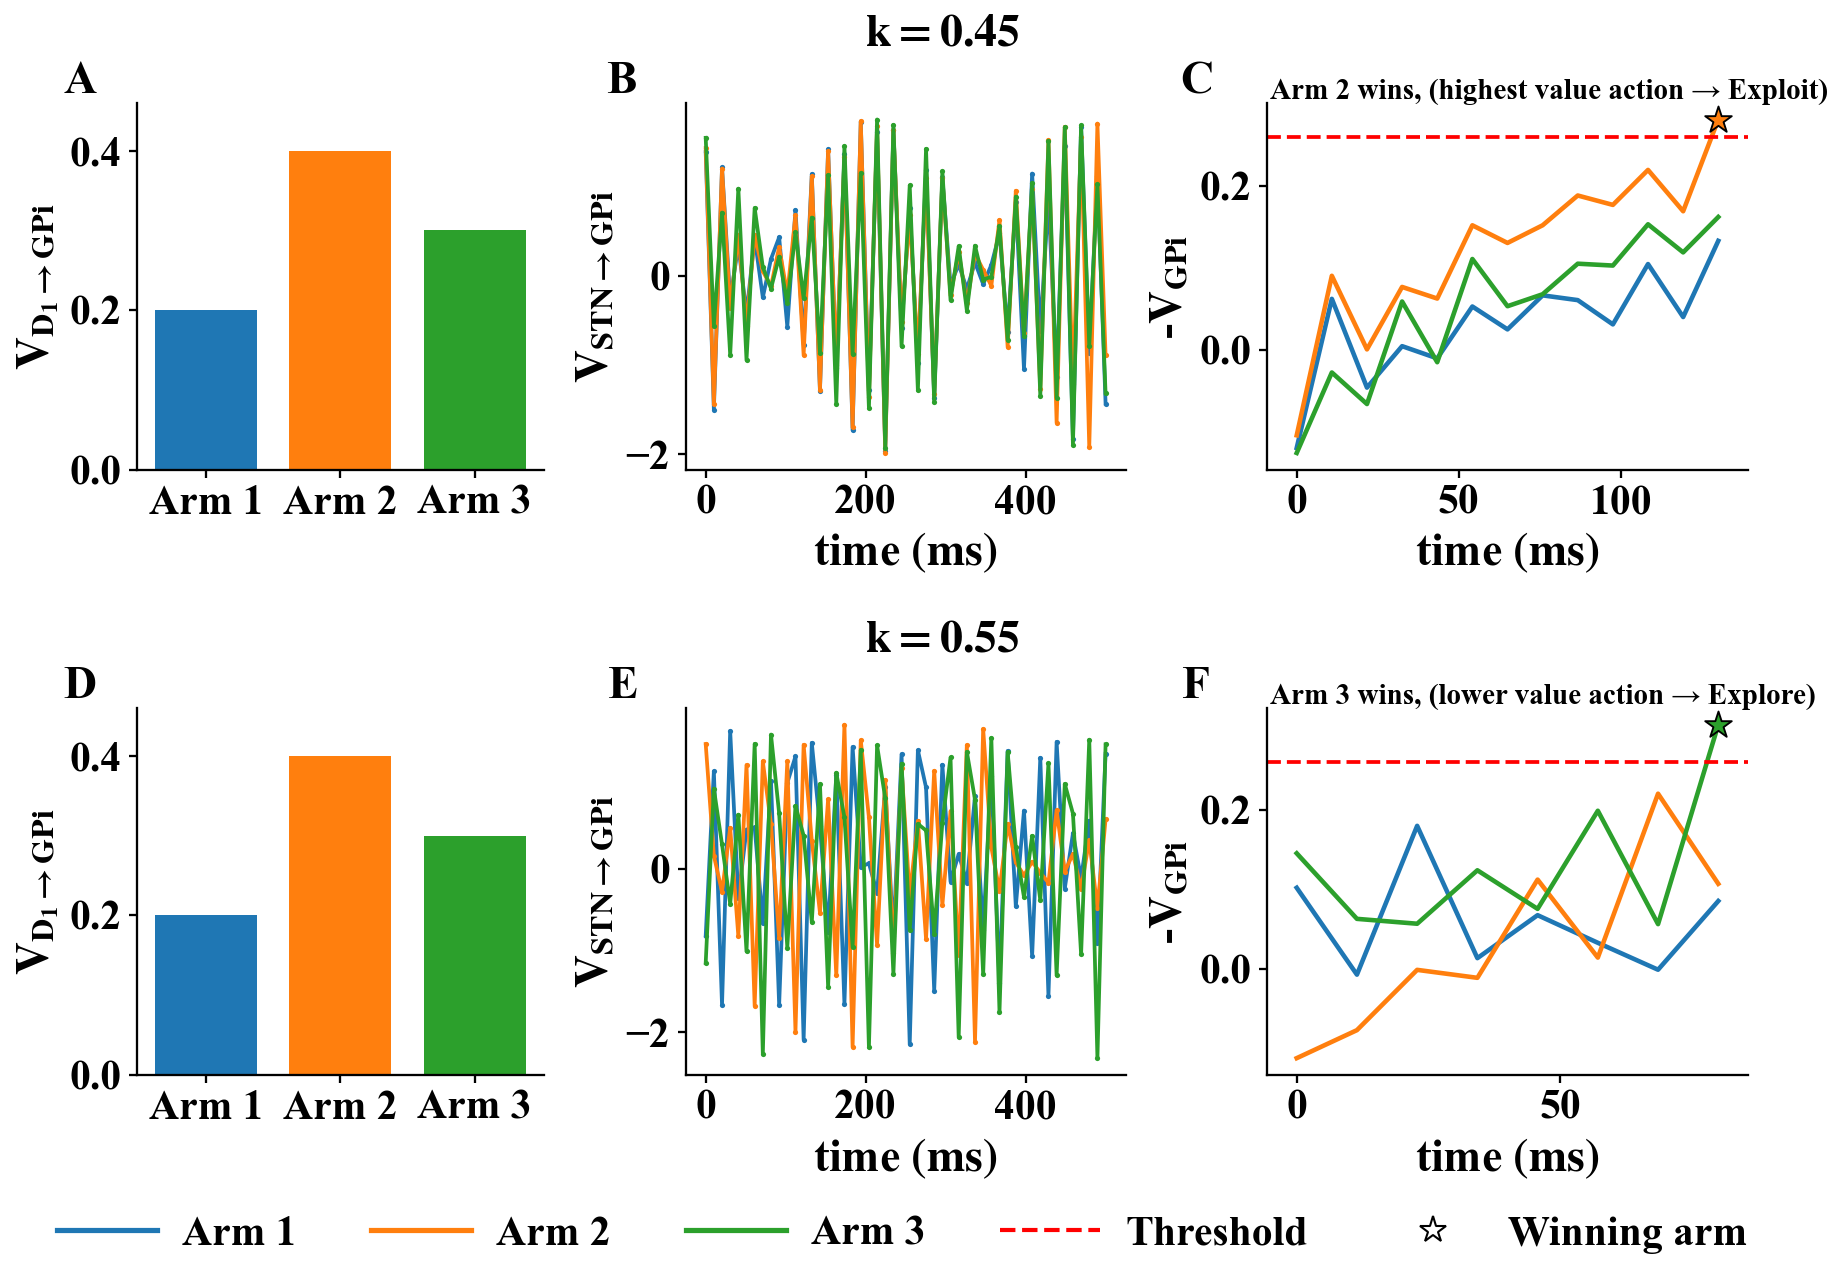

In [7]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Times New Roman",   # or your preferred font
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 22,
    "axes.titlesize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 28,
    "mathtext.default": "bf",           # bold math text
})


fig1 = plt.figure(figsize=(12, 9))
outer1 = fig1.add_gridspec(
    nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.65,
    left=0.075, right=0.97, top=0.86, bottom=0.14
)
letters1 = iter(string.ascii_uppercase)

for r, d in enumerate(cond_data):
    k, sig, tv, w, ct, it, ct_time = d["k"], d["sig"], d["tv"], d["w"], d["ct"], d["it"], d["ct_time"]

    ts_gs = outer1[r].subgridspec(nrows=1, ncols=3, width_ratios=[1.0, 1.08, 1.18], wspace=0.32)

    # -- D1 drive --
    ax_d1 = fig1.add_subplot(ts_gs[0])
    ax_d1.bar(np.arange(num_arms), d1_amp * D1, color=[ac[a] for a in range(num_arms)],
              edgecolor="black", linewidth=0.0, width=0.76)
    ax_d1.set_xticks(np.arange(num_arms))
    ax_d1.set_xticklabels([f"Arm {a+1}" for a in range(num_arms)])
    ax_d1.set_ylabel(r"$V_{\mathrm{D}_1 \rightarrow \mathrm{GPi}}$")
    ax_d1.set_ylim(0, np.max(d1_amp * D1) * 1.15)
    format_axis(ax_d1)
    add_panel_label(ax_d1, next(letters1), dx=-0.18, dy=1.0)

    # -- STN output --
    ax_stn = fig1.add_subplot(ts_gs[1])
    for a in range(num_arms):
        ax_stn.plot(time, sig[a] * d2_amp, color=ac[a], lw=1.8, marker="o", ms=2.5, markeredgewidth=0)
    ax_stn.set_xlabel("time $(ms)$")
    ax_stn.set_ylabel(r"$V_{\mathrm{STN} \rightarrow \mathrm{GPi}}$")
    format_axis(ax_stn)
    add_panel_label(ax_stn, next(letters1), dx=-0.18, dy=1.0)

    # -- GPi race --
    ax_gpi = fig1.add_subplot(ts_gs[2])
    for a in range(num_arms):
        ax_gpi.plot(it, tv[:, a], color=ac[a], lw=2.2)
    ax_gpi.axhline(gpi_threshold, color="red", ls="--", lw=1.8)

    winner_value = tv[ct, w]
    ax_gpi.scatter(ct_time, winner_value, s=180, marker="*", color=ac[w],
                    edgecolor="black", linewidth=0.9, zorder=6)

    tag = "greedy \u2192 EXPLOIT" if w == greedy else "non-greedy \u2192 EXPLORE"
    if ct >= 0.65 * np.max(it):
        x_offset, ha = -46, "center"
    else:
        x_offset, ha = -215, "left"
    if winner_value >= gpi_threshold - 0.05:
        y_offset, va = 20, "top"
    else:
        y_offset, va = 26, "bottom"
    tag = "highest value action → Exploit" if w == greedy else "lower value action → Explore"
    ax_gpi.annotate(f"Arm {w+1} wins, ({tag})", xy=(ct_time, winner_value),
                     xytext=(x_offset, y_offset), textcoords="offset points",
                     ha=ha, va=va, fontsize=14, fontweight="bold", annotation_clip=True)
    ax_gpi.set_xlabel(r"time $(ms)$")
    ax_gpi.set_ylabel(r"-$V_{\mathrm{GPi}}$")
    ax_gpi.margins(x=0.07)
    format_axis(ax_gpi)
    add_panel_label(ax_gpi, next(letters1), dx=-0.18, dy=1.0)

    fig1.canvas.draw()
    block_left = ax_d1.get_position().x0
    block_right = ax_gpi.get_position().x1
    trace_top = max(ax_d1.get_position().y1, ax_stn.get_position().y1, ax_gpi.get_position().y1)

    if r == 0:
        fig1.text(
        (block_left + block_right) / 2,
        trace_top + 0.035,
        rf"$k= 0.45$",
        ha="center",
        va="bottom",
        fontsize=22,
        )
    if r == 1:
        fig1.text(
        (block_left + block_right) / 2,
        trace_top + 0.035,
        rf"$k= 0.55$",
        ha="center",
        va="bottom",
        fontsize=22,
    )


legend_handles = [
    Line2D([0], [0], color=ac[0], lw=2.5, label="Arm 1"),
    Line2D([0], [0], color=ac[1], lw=2.5, label="Arm 2"),
    Line2D([0], [0], color=ac[2], lw=2.5, label="Arm 3"),
    Line2D([0], [0], color="red", lw=2.0, ls="--", label="Threshold"),
    Line2D([0], [0], marker="*", linestyle="none", markerfacecolor="white",
           markeredgecolor="black", markersize=13, label="Winning arm"),
]
fig1.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
            ncol=5, frameon=False, handlelength=2.4, handletextpad=0.6, columnspacing=1.8)

# fig1.suptitle("Action-selection dynamics: D1 drive, STN input, and GPi race", y=0.975, fontsize=24, fontweight = "bold")
plt.show()


## Figure 2 - STN network activity

0
1


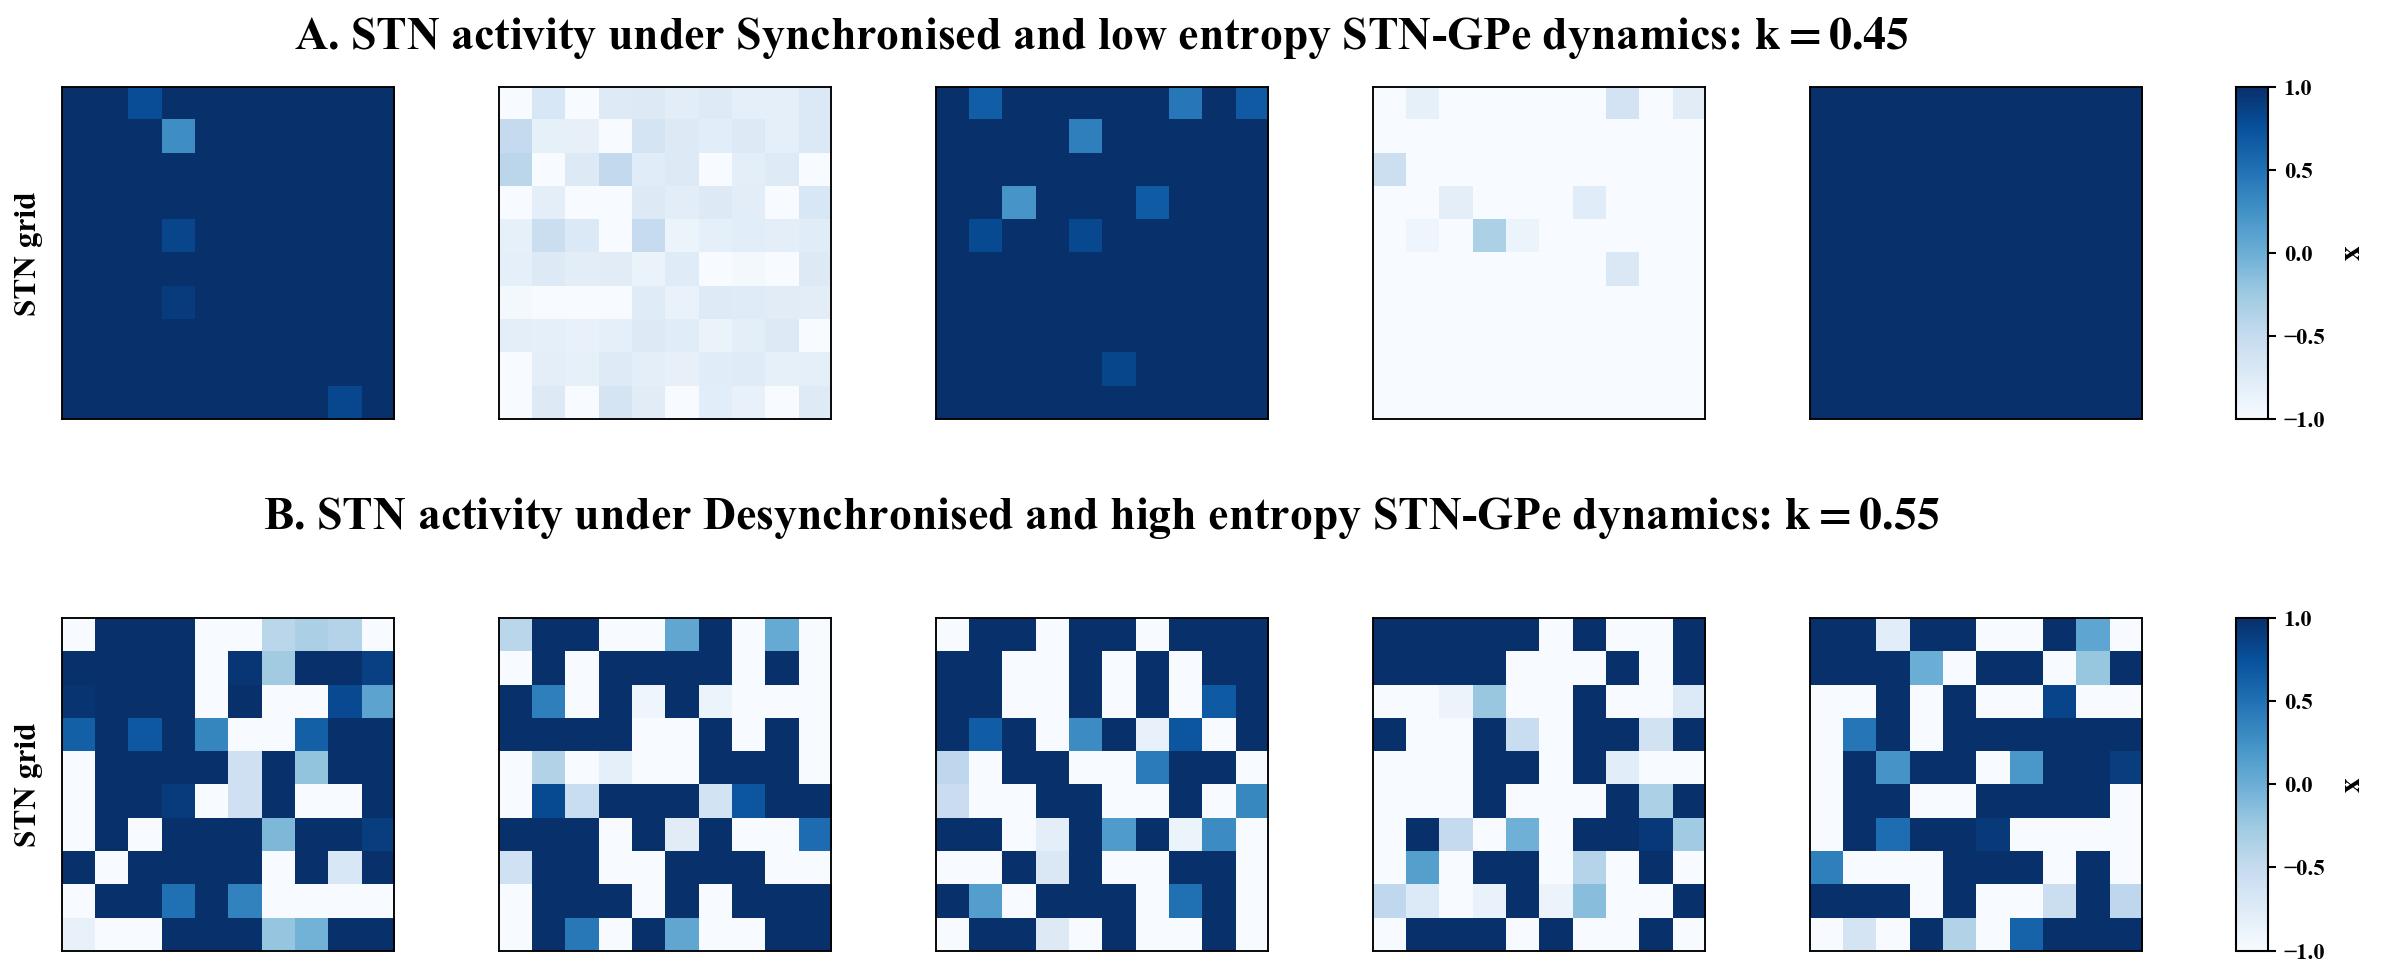

In [8]:
# color scale from the actual data range across both conditions, for a consistent scale
all_frames = np.concatenate([d["grid_frames"] for d in cond_data])
vlim = 1 #np.abs(all_frames).max()

fig2 = plt.figure(figsize=(18, 8))
outer2 = fig2.add_gridspec(
    nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.6,
    left=0.075, right=0.875, top=0.82, bottom=0.10
)
letters2 = iter(string.ascii_uppercase)

for r, d in enumerate(cond_data):
    print(r)
    k, grid_frames = d["k"], d["grid_frames"]

    snap_gs = outer2[r].subgridspec(nrows=1, ncols=n_snap, wspace=0.06)

    snap_axes, im = [], None
    for j, fidx in enumerate(snap_idx):
        ax_snap = fig2.add_subplot(snap_gs[j])
        im = ax_snap.imshow(grid_frames[fidx], vmin=-vlim, vmax=vlim, cmap="Blues",
                             interpolation="nearest", aspect="equal")
        ax_snap.set_xticks([]); ax_snap.set_yticks([])
        for spine in ax_snap.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.9); spine.set_color("black")
        # add_panel_label(ax_snap, next(letters2), dx=-0.05, dy=1.12)
        snap_axes.append(ax_snap)

    snap_axes[0].set_ylabel(r"STN grid", fontsize=15, labelpad=9)

    fig2.canvas.draw()
    block_left = snap_axes[0].get_position().x0
    block_right = snap_axes[-1].get_position().x1
    snap_top = max(ax.get_position().y1 for ax in snap_axes)

    # fig2.text((block_left + block_right) / 2, snap_top + 0.03,
    #           rf"{cond_labels[r]}: $k={k:.3g}$", ha="center", va="bottom",
    #           fontsize=22, fontweight="bold")
    
    if r == 0:
        fig2.text((block_left + block_right) / 2, trace_top + 0.43,
                rf"A. STN activity under {cond_labels[r]}: $k= 0.45$", ha="center", va="bottom",
                fontsize=22, fontweight="bold")
    if r == 1:
        fig2.text((block_left + block_right) / 2, trace_top + 0.03,
                rf"B. STN activity under {cond_labels[r]}: $k= 0.55$", ha="center", va="bottom",
                fontsize=22, fontweight="bold")


    snapshot_bottom = min(ax.get_position().y0 for ax in snap_axes)
    snapshot_top = max(ax.get_position().y1 for ax in snap_axes)
    cax = fig2.add_axes([0.895, snapshot_bottom, 0.012, snapshot_top - snapshot_bottom])
    cbar = fig2.colorbar(im, cax=cax)
    cbar.set_label(r"$x$", fontsize=14, labelpad=7)
    cbar.ax.tick_params(labelsize=11, width=1, length=4)
    cbar.outline.set_linewidth(1)

# fig2.suptitle("STN network activity", y=0.975, fontsize=24, fontweight="bold")

plt.show()
